# Eigenvectors: The Directions That Don't Turn

**This notebook teaches eigenvectors from scratch, it assumes only that a matrix moves vectors around.**

Under a transformation most arrows swing to a new direction. But a few special ones don't turn at all; they only get longer or shorter. Those are the **eigenvectors**, and the factor by which each stretches is its **eigenvalue**. This notebook sweeps a vector around the circle so you can watch almost every direction rotate, and spot the handful that don't.

## Learning objectives

- State what makes $\mathbf{v}$ an **eigenvector** of $A$ and $\lambda$ its **eigenvalue**.
- Identify eigenvectors geometrically as the directions a transformation leaves pointing the same way.
- Explain why a **symmetric** matrix's eigenvectors come out perpendicular, on the axes of the ellipse.

## Background

Applying $A$ to a vector normally changes both its **length** and its **direction**. An **eigenvector** is a nonzero vector whose direction survives:

$$A\mathbf{v} = \lambda\mathbf{v}$$

The output is just a scaled copy of the input. The scalar $\lambda$ is the **eigenvalue**, how much that direction stretches ($|\lambda| > 1$), shrinks ($|\lambda| < 1$), or flips ($\lambda < 0$).

Recall that a matrix sends the unit circle to an **ellipse**. A **symmetric** matrix ($A = A^{\top}$) has real eigenvalues and **perpendicular** eigenvectors, and they lie along the ellipse's long and short axes, which is why the picture below is so clean. That property is the one PCA depends on in §2.7.

## This notebook covers

1. Most directions turn, but not all.
2. The eigenvectors, marked, and their eigenvalues as stretch factors.
3. Eigenvectors scaled by $\lambda$ landing on the ellipse's axes.
4. Symmetric versus non-symmetric matrices.

**Prerequisites:** `U2-4_Transformations-3_UnitCircleAnimation`

**Dataset:** none, matrices are entered directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)
# plotting helper: draw one vector as an arrow starting at `tail`
# (zorder keeps arrows on top of the axis spines, which are the same white)
def arrow(ax, tail, vec, color, label=None, alpha=1.0):
    ax.quiver(tail[0], tail[1], vec[0], vec[1], angles='xy', scale_units='xy',
              scale=1, color=color, label=label, alpha=alpha, width=0.011, zorder=5)

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

## 1. Most directions turn

Take the symmetric matrix $A = \begin{bmatrix}1 & 0.5\\ 0.5 & 1\end{bmatrix}$ and try it on a few vectors. For most of them the output arrow points somewhere new, the angle between input and output is not zero.

But try $\begin{bmatrix}1\\1\end{bmatrix}$: the output is $\begin{bmatrix}1.5\\1.5\end{bmatrix}$, the *same direction*, exactly $1.5$ times as long. That is an eigenvector with eigenvalue $1.5$.

In [2]:
A = np.array([[1.0, 0.5],
              [0.5, 1.0]])
helpers.show(A, name="A")

tests = {"[1, 0]": np.array([1.0, 0.0]),
         "[0, 1]": np.array([0.0, 1.0]),
         "[2, 1]": np.array([2.0, 1.0]),
         "[1, 1]": np.array([1.0, 1.0]),
         "[1, -1]": np.array([1.0, -1.0])}

for name, v in tests.items():
    Av = A @ v
    # angle between v and Av, in degrees
    cos = np.dot(v, Av) / (np.linalg.norm(v) * np.linalg.norm(Av))
    turn = np.degrees(np.arccos(np.clip(cos, -1, 1)))
    tag = "  <- direction unchanged!" if np.isclose(turn, 0) or np.isclose(turn, 180) else ""
    print(f"v = {name:<8} ->  Av = [{Av[0]:5.2f}, {Av[1]:5.2f}]   turned {turn:5.1f} deg{tag}")

<IPython.core.display.Math object>

v = [1, 0]   ->  Av = [ 1.00,  0.50]   turned  26.6 deg
v = [0, 1]   ->  Av = [ 0.50,  1.00]   turned  26.6 deg
v = [2, 1]   ->  Av = [ 2.50,  2.00]   turned  12.1 deg
v = [1, 1]   ->  Av = [ 1.50,  1.50]   turned   0.0 deg  <- direction unchanged!
v = [1, -1]  ->  Av = [ 0.50, -0.50]   turned   0.0 deg


## 2. The two special directions

`np.linalg.eig` finds them for us. For this $A$ there are two: $\begin{bmatrix}1\\1\end{bmatrix}$ with $\lambda = 1.5$, and $\begin{bmatrix}1\\-1\end{bmatrix}$ with $\lambda = 0.5$. NumPy returns them scaled to length 1, and as the **columns** of the returned matrix.

So $A$ stretches by $1.5$ along one diagonal and squashes by $0.5$ along the other, and does nothing else. That is the entire content of the transformation, expressed in the right two directions.

In [3]:
eigenvalues, eigenvectors = np.linalg.eig(A)

for k in range(2):
    lam, v = eigenvalues[k], eigenvectors[:, k]
    helpers.show(np.round(v, 3), label=f"eigenvector {k+1}, eigenvalue {lam:.2f}")
    # the defining property, checked
    print(f"   A v = [{(A @ v)[0]:.3f}, {(A @ v)[1]:.3f}]   "
          f"lambda v = [{(lam * v)[0]:.3f}, {(lam * v)[1]:.3f}]   equal? {np.allclose(A @ v, lam * v)}")

print(f"\nperpendicular to each other? dot product = "
      f"{np.dot(eigenvectors[:, 0], eigenvectors[:, 1]):.1e}  (symmetric matrix)")

<IPython.core.display.Math object>

   A v = [1.061, 1.061]   lambda v = [1.061, 1.061]   equal? True


<IPython.core.display.Math object>

   A v = [-0.354, 0.354]   lambda v = [-0.354, 0.354]   equal? True

perpendicular to each other? dot product = 0.0e+00  (symmetric matrix)


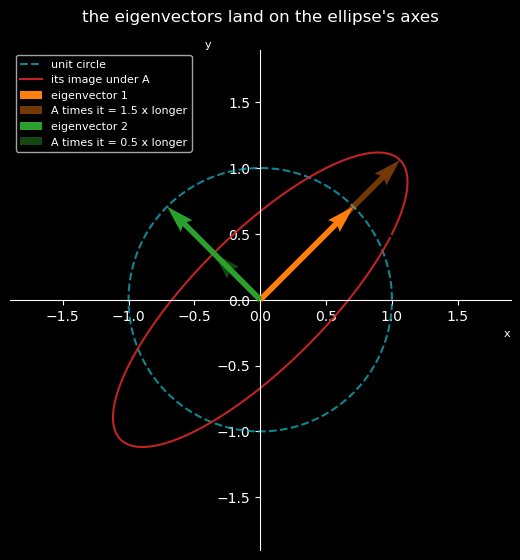

In [4]:
n_pts = 200
angles = np.linspace(0, 2 * np.pi, n_pts, endpoint=False)
circle = np.array([np.cos(angles), np.sin(angles)])
ellipse = A @ circle

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot(circle[0], circle[1], "--", color="tab:cyan", alpha=0.7, label="unit circle")
ax.plot(ellipse[0], ellipse[1], "-", color="tab:red", alpha=0.9, label="its image under A")

# each eigenvector, and the same eigenvector scaled by its eigenvalue
for k, color in zip(range(2), ["tab:orange", "tab:green"]):
    v, lam = eigenvectors[:, k], eigenvalues[k]
    arrow(ax, (0, 0), v, color, f"eigenvector {k+1}")
    arrow(ax, (0, 0), lam * v, color, f"A times it = {lam:.1f} x longer", alpha=0.45)

center_axes(ax); label_axes(ax)
ax.set_xlim(-1.9, 1.9); ax.set_ylim(-1.9, 1.9); ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=8)
ax.set_title("the eigenvectors land on the ellipse's axes", pad=20)
plt.show()

The eigenvectors point exactly along the ellipse's **long and short axes**, and scaling each by its eigenvalue lands it precisely on the ellipse. That is what "this direction is only stretched" looks like.

This clean right-angle picture is not luck, it happens because $A$ is **symmetric**. Section 4 shows what a non-symmetric matrix does instead.

## 3. The animation

Sweep a vector all the way around the circle and watch its image. Most of the time the two arrows point in visibly different directions. Four times per revolution, at the two eigen-directions and their opposites, they line up exactly.

*(Press play. The animation code is mechanics.)*

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(circle[0], circle[1], "--", color="tab:cyan", alpha=0.4)
ax.plot(ellipse[0], ellipse[1], "--", color="tab:red", alpha=0.4)
for k in range(2):
    v = eigenvectors[:, k] * 1.8
    ax.plot([-v[0], v[0]], [-v[1], v[1]], ":", color="tab:orange", lw=1.2)
center_axes(ax); label_axes(ax)
ax.set_xlim(-1.9, 1.9); ax.set_ylim(-1.9, 1.9); ax.set_aspect("equal")
ax.set_title("v (cyan) and Av (red); dotted = eigen-directions", pad=15, fontsize=10)

before, = ax.plot([], [], color="tab:cyan", lw=2.5)
after,  = ax.plot([], [], color="tab:red", lw=2.5)

n_frames = 36
step = n_pts // n_frames

def animate(i):
    v = circle[:, i * step]
    Av = A @ v
    before.set_data([0, v[0]], [0, v[1]])
    after.set_data([0, Av[0]], [0, Av[1]])
    return before, after

ani = FuncAnimation(fig, animate, frames=n_frames, blit=True, interval=120, repeat=True)
plt.close(fig)
HTML(ani.to_jshtml())

## 4. Symmetric or not

The perpendicular eigenvectors above came from $A$ being **symmetric**, equal to its own transpose. Symmetric matrices always behave this well: real eigenvalues, perpendicular eigenvectors.

Drop the symmetry and things get messier. A **rotation** matrix is the extreme case: it turns *every* direction, so no real eigenvector can exist, and NumPy returns **complex** eigenvalues to say so. Complex eigenvalues are the algebra's way of reporting "this transformation rotates."

The covariance matrix that PCA is built on is always symmetric, which is exactly why PCA always produces clean perpendicular axes.

In [6]:
examples = {
    "symmetric":     np.array([[1.0, 0.5], [0.5, 1.0]]),
    "non-symmetric": np.array([[2.0, 1.0], [0.0, 3.0]]),
    "rotation 60":   np.array([[np.cos(np.radians(60)), -np.sin(np.radians(60))],
                               [np.sin(np.radians(60)),  np.cos(np.radians(60))]]),
}

for name, M in examples.items():
    vals, vecs = np.linalg.eig(M)
    print(f"{name:<14} symmetric? {np.allclose(M, M.T)!s:<5}  eigenvalues: {np.round(vals, 3)}")
    if np.isrealobj(vals):
        perp = np.dot(vecs[:, 0], vecs[:, 1])
        print(f"{'':<14} eigenvectors perpendicular? dot = {perp:+.3f}")
    else:
        print(f"{'':<14} complex -> no real direction survives; it rotates everything")

symmetric      symmetric? True   eigenvalues: [1.5 0.5]
               eigenvectors perpendicular? dot = +0.000
non-symmetric  symmetric? False  eigenvalues: [2. 3.]
               eigenvectors perpendicular? dot = +0.707
rotation 60    symmetric? False  eigenvalues: [0.5+0.866j 0.5-0.866j]
               complex -> no real direction survives; it rotates everything


## 5. Summary

- An **eigenvector** satisfies $A\mathbf{v} = \lambda\mathbf{v}$: the transformation scales it without turning it. The scale factor $\lambda$ is its **eigenvalue**.
- Geometrically the eigenvectors lie along the **axes of the ellipse** that $A$ makes from the unit circle.
- **Symmetric** matrices have real eigenvalues and **perpendicular** eigenvectors: the property PCA relies on.
- **Complex** eigenvalues mean no direction survives: the transformation rotates.

Next: computing them by hand, with the determinant from §2.5 (`U2-6_Eigen-2_CharacteristicEquation`).